# Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Master Dataset

Load the master dataset generated during the preprocessing stage. This dataset contains the merged sustainability reports, ESG information, and generated claim features.

In [3]:
merged = pd.read_csv("Master_Dataset.csv")

# Remove unnecessary index column if it exists
if "Unnamed: 0" in merged.columns:
    merged = merged.drop(columns=["Unnamed: 0"])

print(merged.head())

           filename ticker  year  \
0  ASX_BSX_2020.pdf    BSX  2020   
1  ASX_BSX_2022.pdf    BSX  2022   
2  ASX_EXR_2022.pdf    EXR  2022   
3  LSE_ADM_2019.pdf    ADM  2019   
4  LSE_ADM_2020.pdf    ADM  2020   

                                preprocessed_content  \
0  style guide colour colour use imagecolour prof...   
1  sustainability report look mining green office...   
2  report environment social governance esg basel...   
3  corporate social responsibilty report introduc...   
4  sustainability admiral commit maintain respons...   

                                        ner_entities  e_score  s_score  \
0  ['bk%', 'rgb', 'un', 'el ectric mine consortiu...     3.16    18.00   
1  ['murray street', 'west perth', 'west perth', ...     2.83    12.86   
2  ['september', 'mongolia', 'australia', 'austra...     3.81     4.28   
3  ['david stevens', 'csr board', 'just over  yea...    16.38    14.20   
4  ['year', 'health & wellbeing', 'a -month', 'on...    15.89    13.51   

 

# Create Commitment-Action Alignment Table

In [4]:
commitment_keywords = [
    "commitment",
    "future",
    "goal",
    "vision",
    "ambition",
    "pledge",
    "aspiration",
    "promise",
    "target"
]

action_keywords = [
    "reduced",
    "reduction",
    "achieved",
    "implemented",
    "completed",
    "installed",
    "decreased",
    "improved",
    "delivered",
    "measured",
    "verified",
    "audited"
]

print("Commitment Keywords:", commitment_keywords)
print("Action Keywords:", action_keywords)

Commitment Keywords: ['commitment', 'future', 'goal', 'vision', 'ambition', 'pledge', 'aspiration', 'promise', 'target']
Action Keywords: ['reduced', 'reduction', 'achieved', 'implemented', 'completed', 'installed', 'decreased', 'improved', 'delivered', 'measured', 'verified', 'audited']


In [5]:
def count_words(text, words):
    text = str(text).lower()

    count = 0

    for word in words:
        count += text.count(word)

    return count


merged['commitment_score'] = merged['preprocessed_content'].apply(
    lambda x: count_words(x, commitment_keywords)
)

merged['action_score'] = merged['preprocessed_content'].apply(
    lambda x: count_words(x, action_keywords)
)

print(
    merged[
        [
            'ticker',
            'commitment_score',
            'action_score'
        ]
    ].head()
)

  ticker  commitment_score  action_score
0    BSX                73             2
1    BSX                52             9
2    EXR                 7             1
3    ADM                20             4
4    ADM                49             7


In [6]:
merged['alignment_score'] = (
    merged['action_score'] /
    (merged['commitment_score'] + 1)
)

print(
    merged[
        [
            'ticker',
            'commitment_score',
            'action_score',
            'alignment_score'
        ]
    ].head()
)

  ticker  commitment_score  action_score  alignment_score
0    BSX                73             2         0.027027
1    BSX                52             9         0.169811
2    EXR                 7             1         0.125000
3    ADM                20             4         0.190476
4    ADM                49             7         0.140000


In [7]:
lowest_alignment = merged.sort_values(
    by='alignment_score'
)

print(
    lowest_alignment[
        [
            'ticker',
            'Name',
            'commitment_score',
            'action_score',
            'alignment_score'
        ]
    ].head(10)
)

    ticker                        Name  commitment_score  action_score  \
858    ABT         Abbott Laboratories                15             0   
822    WFC           Wells Fargo & Co.                17             0   
811    VTR                Ventas, Inc.                 2             0   
23    AKAM     Akamai Technologies Inc                23             0   
310    AJG   Arthur J. Gallagher & Co.                26             0   
311    AJG   Arthur J. Gallagher & Co.                32             0   
315    AMP  Ameriprise Financial, Inc.                48             0   
309    AJG   Arthur J. Gallagher & Co.                 7             0   
64   CMCSA                Comcast Corp                13             0   
316    AMP  Ameriprise Financial, Inc.                48             0   

     alignment_score  
858              0.0  
822              0.0  
811              0.0  
23               0.0  
310              0.0  
311              0.0  
315              0.0  
3

In [8]:
print(merged.columns.tolist())

['filename', 'ticker', 'year', 'preprocessed_content', 'ner_entities', 'e_score', 's_score', 'g_score', 'total_score', 'Symbol', 'Name', 'Address', 'Sector', 'Industry', 'Full Time Employees', 'Description', 'Total ESG Risk score', 'Environment Risk Score', 'Governance Risk Score', 'Social Risk Score', 'Controversy Level', 'Controversy Score', 'ESG Risk Percentile', 'ESG Risk Level', 'concrete_count', 'vague_count', 'unverifiable_count', 'claim_type', 'commitment_score', 'action_score', 'alignment_score']


In [9]:
rq4_table = lowest_alignment[
    [
        'ticker',
        'Name',
        'commitment_score',
        'action_score',
        'alignment_score'
    ]
].head(10)

print(rq4_table)

rq4_table.to_csv(
    "RQ4_Lowest_Alignment_Companies.csv",
    index=False
)

    ticker                        Name  commitment_score  action_score  \
858    ABT         Abbott Laboratories                15             0   
822    WFC           Wells Fargo & Co.                17             0   
811    VTR                Ventas, Inc.                 2             0   
23    AKAM     Akamai Technologies Inc                23             0   
310    AJG   Arthur J. Gallagher & Co.                26             0   
311    AJG   Arthur J. Gallagher & Co.                32             0   
315    AMP  Ameriprise Financial, Inc.                48             0   
309    AJG   Arthur J. Gallagher & Co.                 7             0   
64   CMCSA                Comcast Corp                13             0   
316    AMP  Ameriprise Financial, Inc.                48             0   

     alignment_score  
858              0.0  
822              0.0  
811              0.0  
23               0.0  
310              0.0  
311              0.0  
315              0.0  
3

# Visualize Commitment-Action Alignment

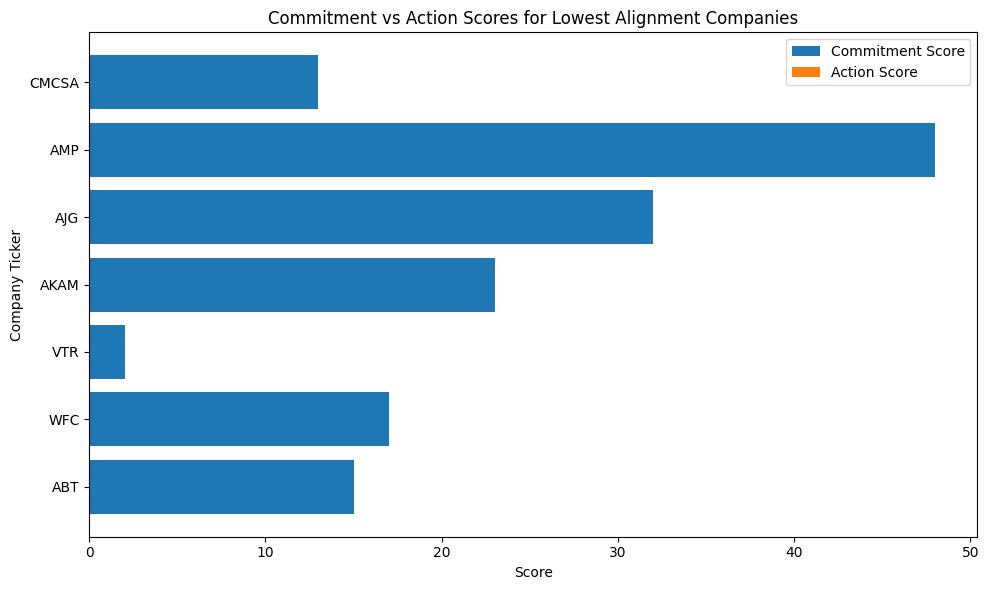

In [10]:
top10 = lowest_alignment.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10['ticker'],
    top10['commitment_score'],
    label='Commitment Score'
)

plt.barh(
    top10['ticker'],
    top10['action_score'],
    label='Action Score'
)

plt.title("Commitment vs Action Scores for Lowest Alignment Companies")
plt.xlabel("Score")
plt.ylabel("Company Ticker")

plt.legend()
plt.tight_layout()

plt.savefig(
    "RQ4_Commitment_vs_Action_Alignment.pdf",
    bbox_inches="tight"
)

plt.show()

# Save Figure and Table

In [11]:
rq4_table.to_csv(
    "RQ4_Lowest_Alignment_Companies.csv",
    index=False
)

print("RQ4 table saved successfully.")

RQ4 table saved successfully.
